eda + k means clustering + boxplots/scatterplots

In [22]:
import pandas as pd
import numpy as np 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [151]:
heart_data=pd.read_csv('heart.csv')
heart_data.dropna() #, heart_data.info
x_data=pd.DataFrame(StandardScaler().fit_transform(heart_data.drop(columns=['target'])))
#x_data['target']=heart_data['target']
heart_data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

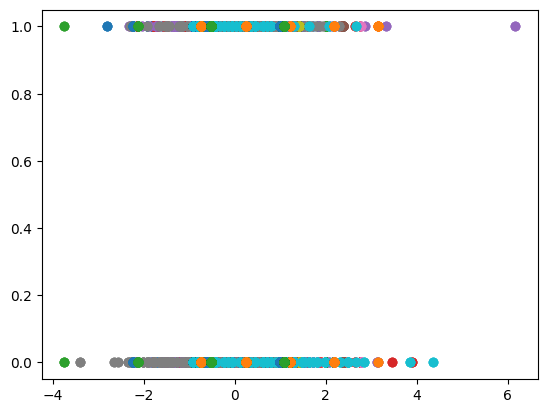

In [152]:
for column in x_data.columns:
   plt.scatter(x=x_data[column],y=heart_data['target'])


In [153]:
y_data=heart_data['target']
clusters=KMeans().fit_predict(x_data)

kmeans = KMeans(n_clusters=2, random_state=42)
train_clusters = kmeans.fit_predict(x_data)


clusters_df = pd.DataFrame({
    'cluster': train_clusters,
    'target': y_data.reset_index(drop=True)  
})


cluster_means = clusters_df.groupby('cluster')['target'].mean()
print(cluster_means)



cluster
0    0.107050
1    0.755452
Name: target, dtype: float64
